## 📐 Gradients

**Concepts:** [Choosing a router](../routers.md#choosing-a-router)

This notebook uses _OptiWindNet_’s [gradient()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.gradient) method to analyze how small changes in turbine or substation positions affect total cable length and cost. The examples calculate length and cost gradients, compare them with the expected behavior, and temporarily substitute coordinates without modifying the underlying network object.

The gradient holds the selected links, routing vertices and cable types fixed. It describes local changes in the current network's length or cost, not a derivative through a fresh routing solve. Re-optimization can change the topology discontinuously. If new coordinates are passed, the gradients evaluated based on the previously optimized routes, now mapped to the new coordinates, and do not modify the stored network.

### Import required packages

In [ ]:
import numpy as np
from tabulate import tabulate

from optiwindnet.api import WindFarmNetwork

In [2]:
# Display figures as SVG in Jupyter notebooks
%config InlineBackend.figure_formats = ['svg']

### A sample network

Create a sample network with one substation and two wind turbines.

In [3]:
substationsC = np.array([[0, 0]])
turbinesC = np.array([[0, 1], [1, 1]])
borderC = np.array([[-0.1, -0.1], [-0.1, 1.1], [1.1, 1.1], [1.1, -0.1]], dtype=float)

Create an instance of WindFarmNetwork based on the defined data.

In [4]:
wfn = WindFarmNetwork(
    turbinesC=turbinesC,
    substationsC=substationsC,
    cables=[(5, 1800.0)],
    borderC=borderC,
)

Plot the location geometry (without any electrical network)

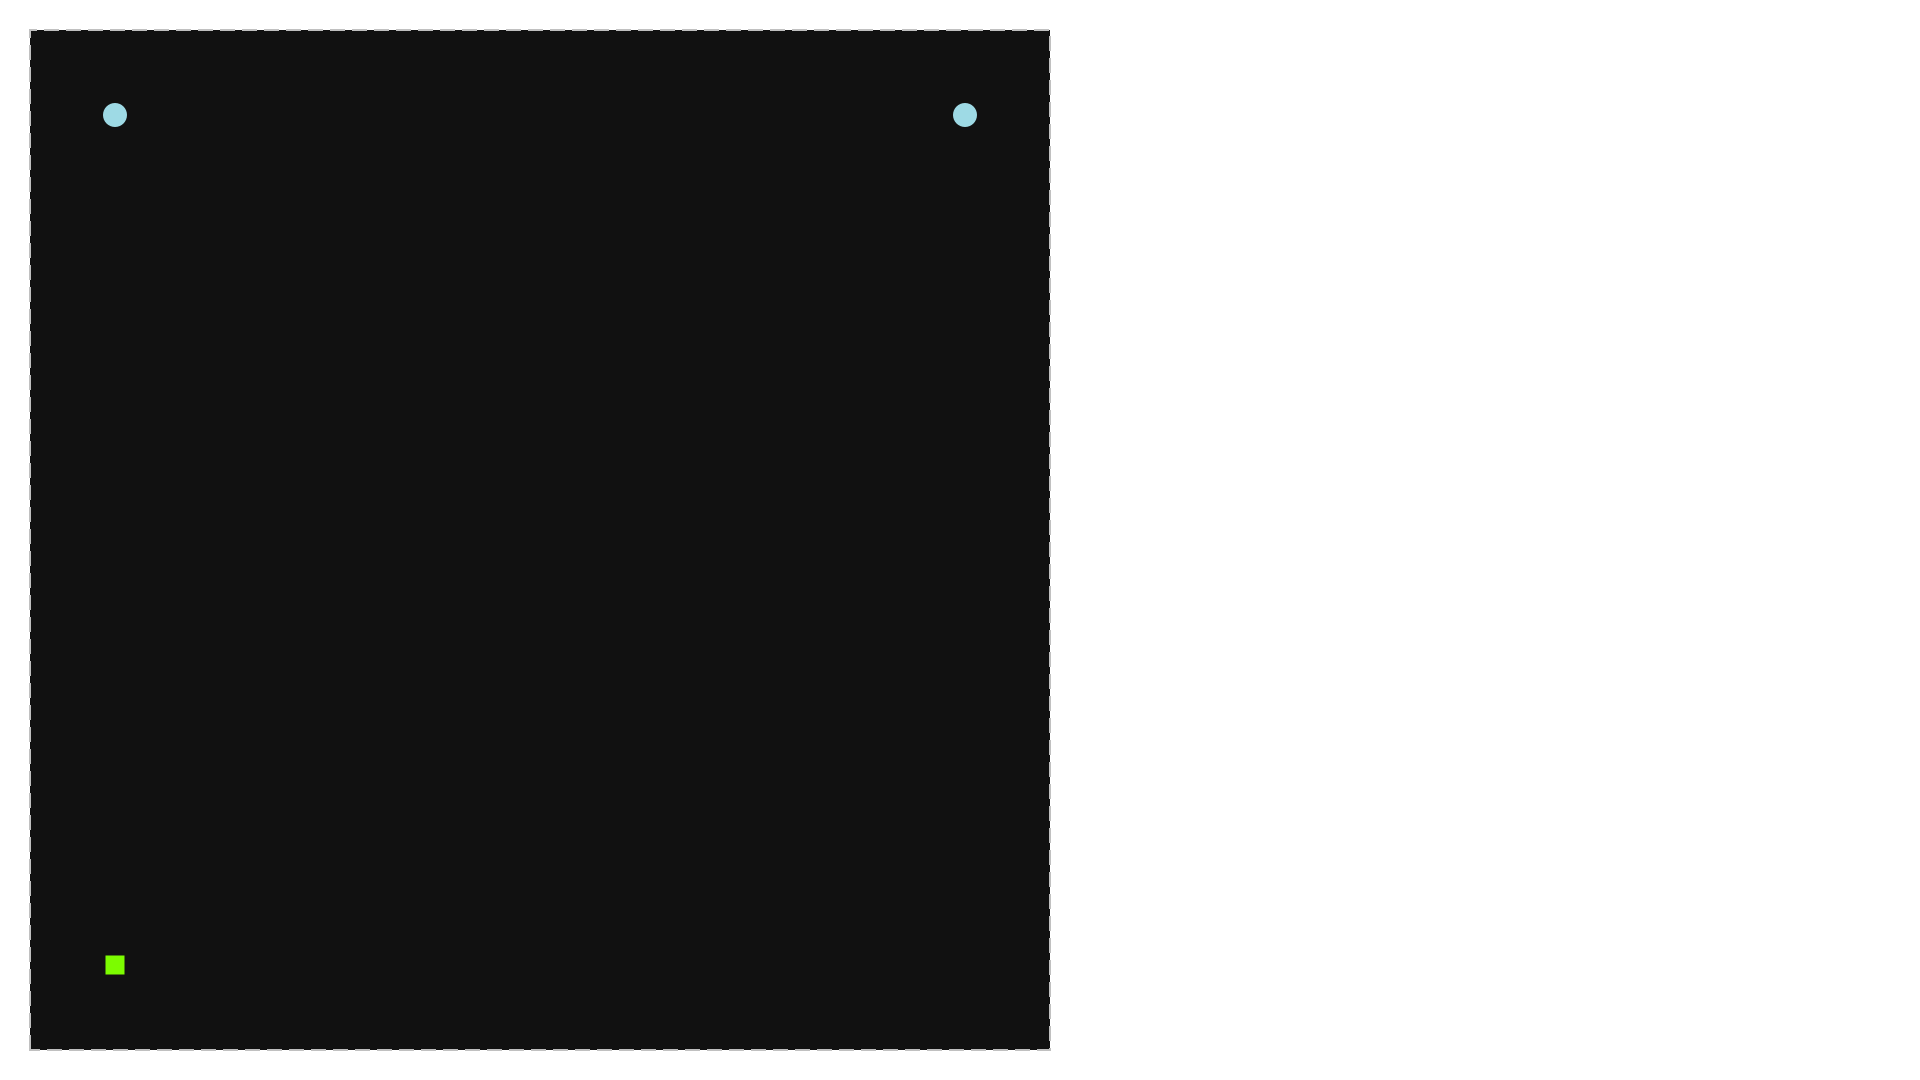

In [5]:
wfn  # or wfn.plot_location()

#### Optimize

Run optimization with the default solver.

In [6]:
res_optimize = wfn.optimize()

Plot optimized network.

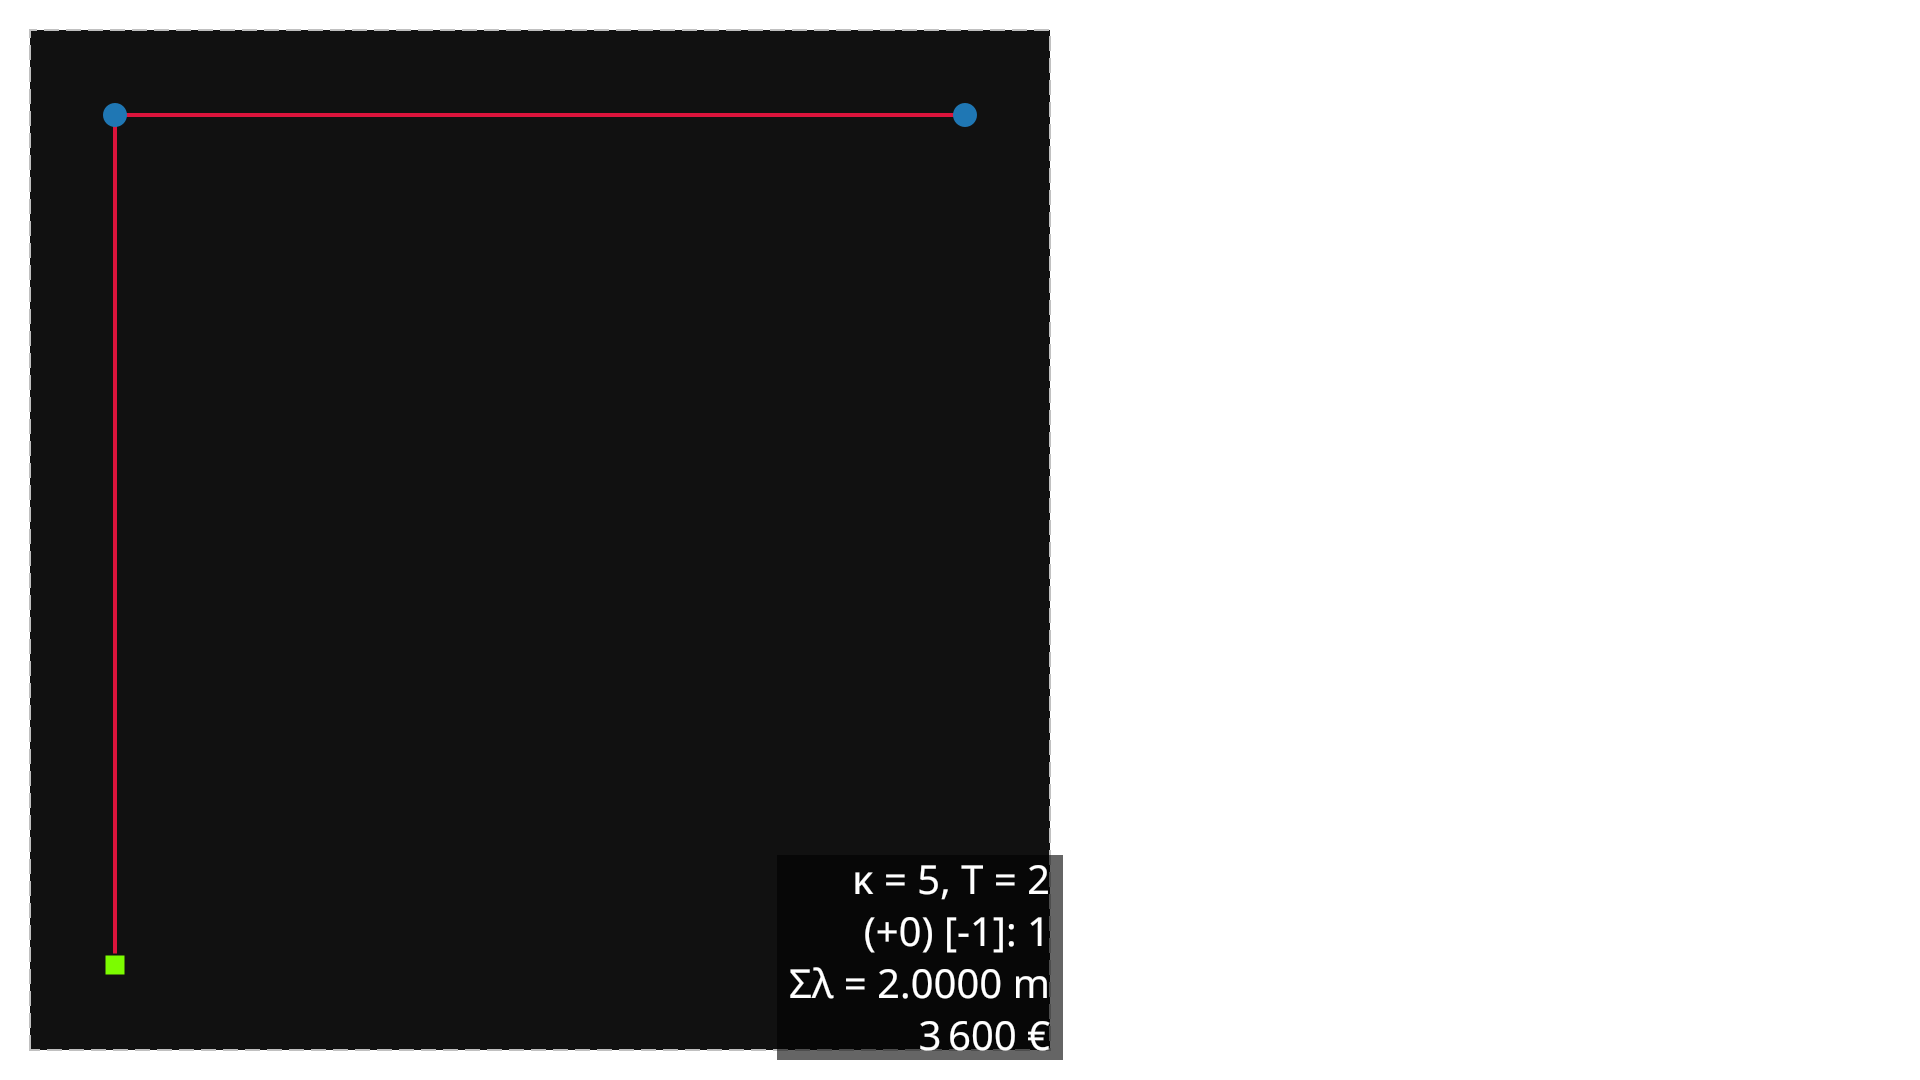

In [7]:
wfn

### Calculate gradients

#### Gradient of length (default)

For the plotted path, the first turbine is joined to the substation below and the second turbine to its right. Its length gradient is therefore `(-1, 1)`: a small move to the right shortens one segment, while a move upwards lengthens the other. The gradients for the other turbine and substation follow from their incident segments.

In [ ]:
def gradient_table(grad_wts, grad_ss):
    """Tabulate turbine and substation gradients, one row per node."""
    R = len(grad_ss)
    rows = [('turbine', n, *xy) for n, xy in enumerate(grad_wts.tolist())]
    rows += [('substation', n - R, *xy) for n, xy in enumerate(grad_ss.tolist())]
    return tabulate(rows, headers=('', 'node', '∂/∂x', '∂/∂y'), tablefmt='html')


grad_wts, grad_ss = wfn.gradient()
gradient_table(grad_wts, grad_ss)

#### Gradient of cost

In [ ]:
grad_wts, grad_ss = wfn.gradient(gradient_type='cost')
gradient_table(grad_wts, grad_ss)

##### Gradient with new coordinates

Example 1

In [ ]:
grad_wts, grad_ss = wfn.gradient(substationsC=np.array([[0.5, 0]], dtype=float))
gradient_table(grad_wts, grad_ss)

Example 2

In [ ]:
grad_wts, grad_ss = wfn.gradient(substationsC=np.array([[-1, 1]], dtype=float))
gradient_table(grad_wts, grad_ss)

> Note: [.gradient()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.gradient) calculates gradients with new coordinates but **does not update the `wfn` instance**. Plotting the network still shows the original coordinates. To update `wfn`, see [the WindFarmNetwork class](hi10_windfarmnetwork.ipynb).

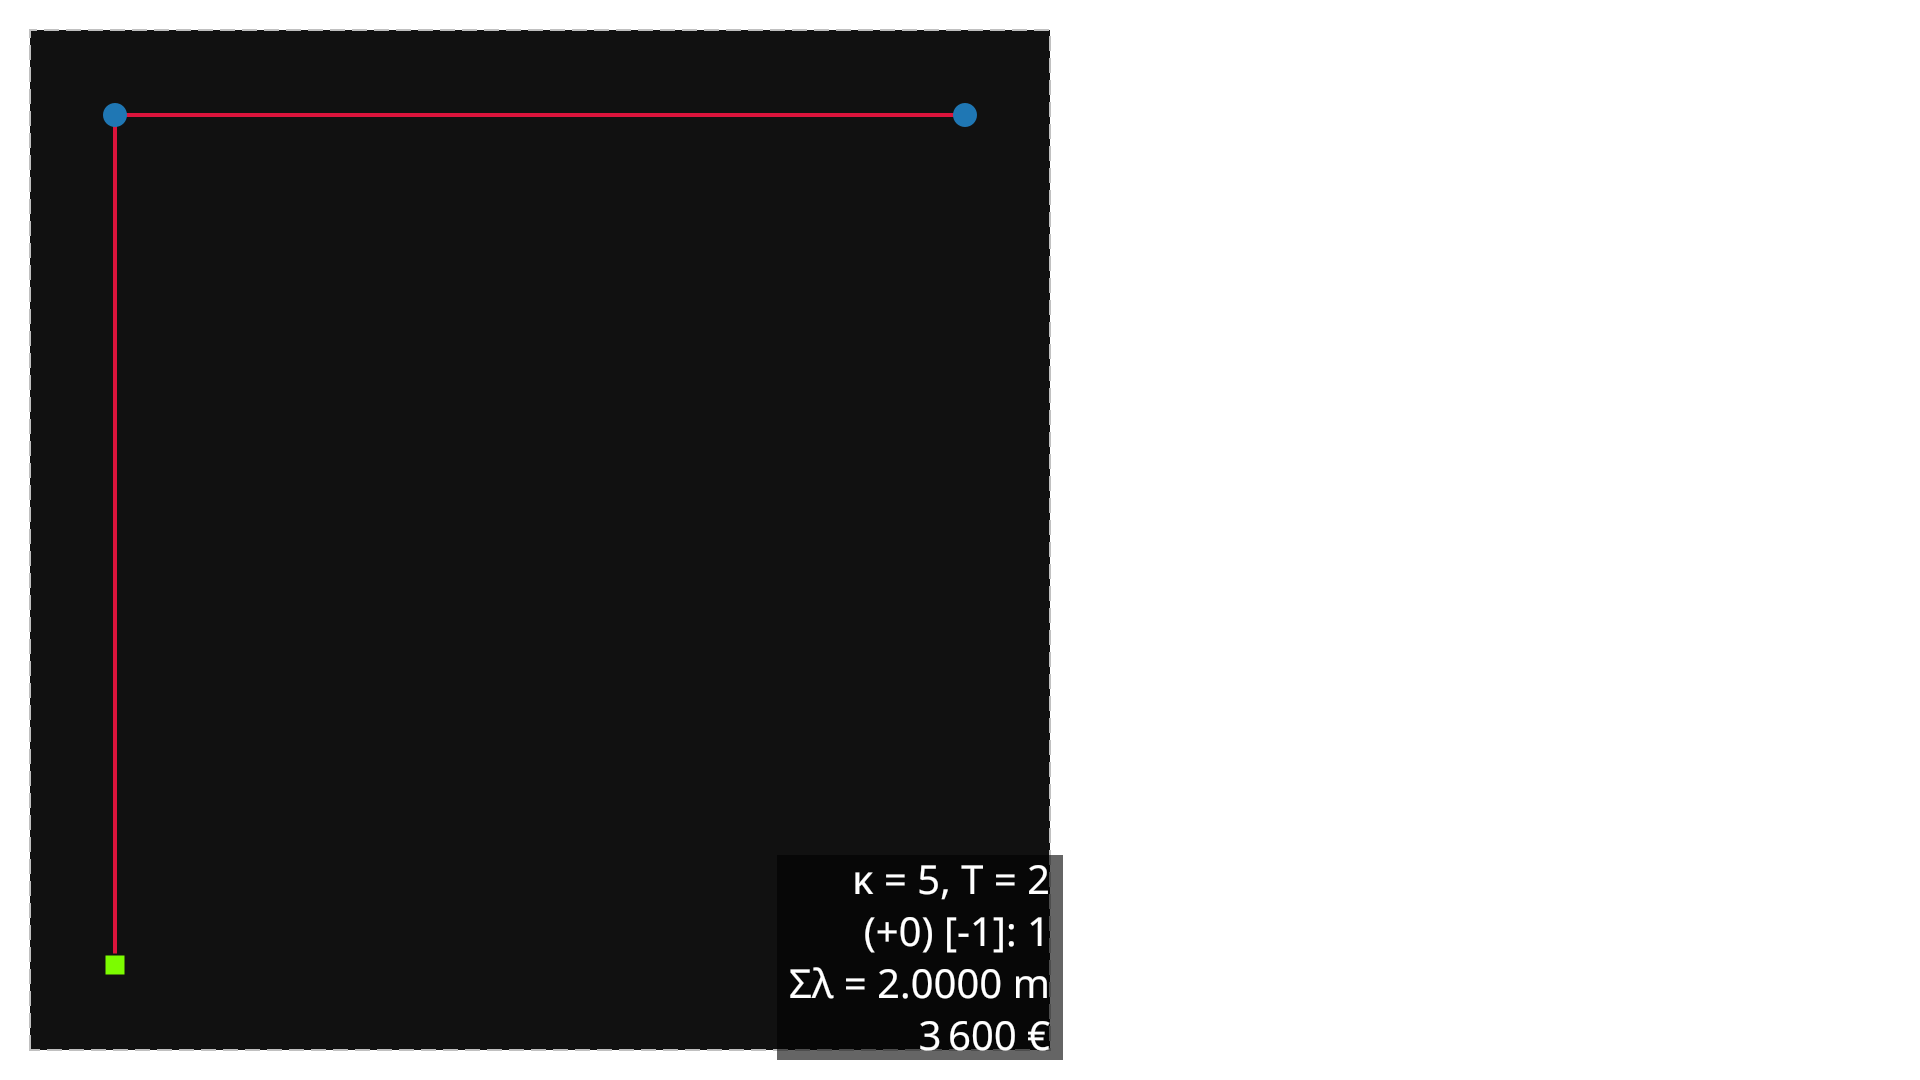

In [12]:
wfn